# Coursework - Rowan d'Auria (rd761)

## Data Exploration
> _Become one with the data_

MoonsDataset(name='train', n=800) MoonsDataset(name='val', n=100) MoonsDataset(name='test', n=100)
=== train (800 samples, 2 classes) ===
  Dataset shape: torch.Size([800, 2])
  Class counts: {0: 385, 1: 415}
  x1: mean=0.521, std=0.874, range=[-1.127, 2.067]
  x2: mean=0.231, std=0.491, range=[-0.610, 1.201]
  class_0: mean=[0.001268340740352869, 0.6216179728507996], std=[0.717052698135376, 0.3202870488166809]
  class_1: mean=[1.0032110214233398, -0.13077937066555023], std=[0.7164219617843628, 0.31061533093452454]

  Duplicates: 0, NaNs: 0
  Correlation(x1, x2): -0.4347

=== val (100 samples, 2 classes) ===
  Dataset shape: torch.Size([100, 2])
  Class counts: {0: 56, 1: 44}
  x1: mean=0.461, std=0.796, range=[-1.003, 2.029]
  x2: mean=0.334, std=0.541, range=[-0.579, 1.078]
  class_0: mean=[0.05057208612561226, 0.7256950736045837], std=[0.6229149699211121, 0.28358083963394165]
  class_1: mean=[0.9824522137641907, -0.16392913460731506], std=[0.6777079105377197, 0.34579598903656006]

 

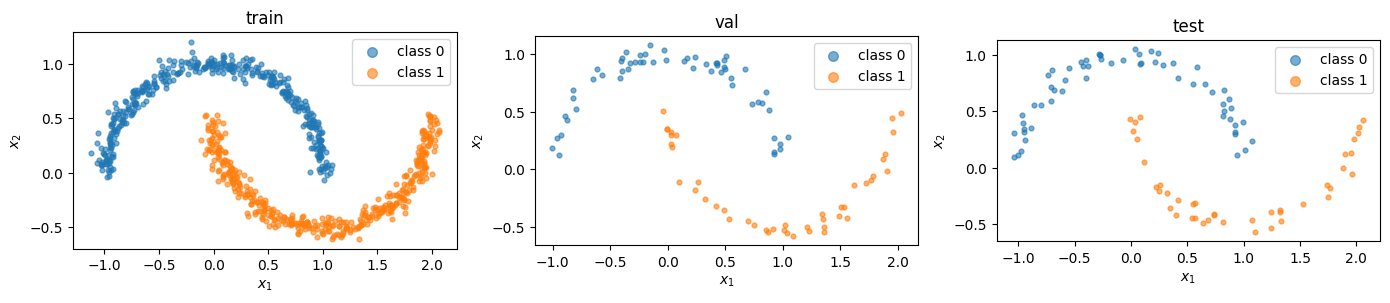

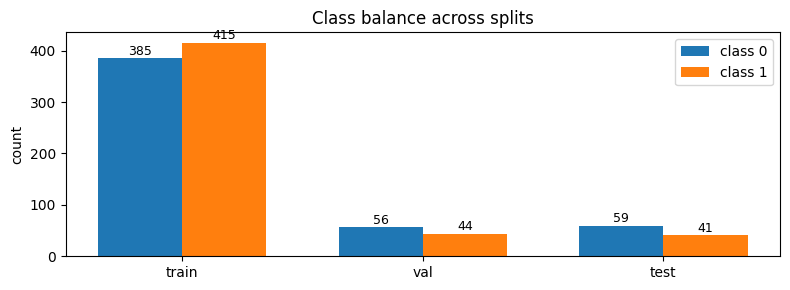

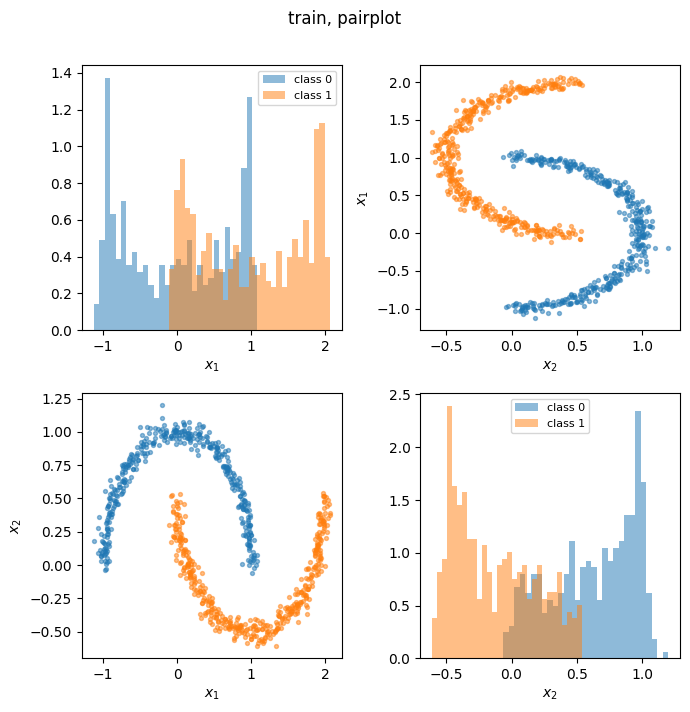

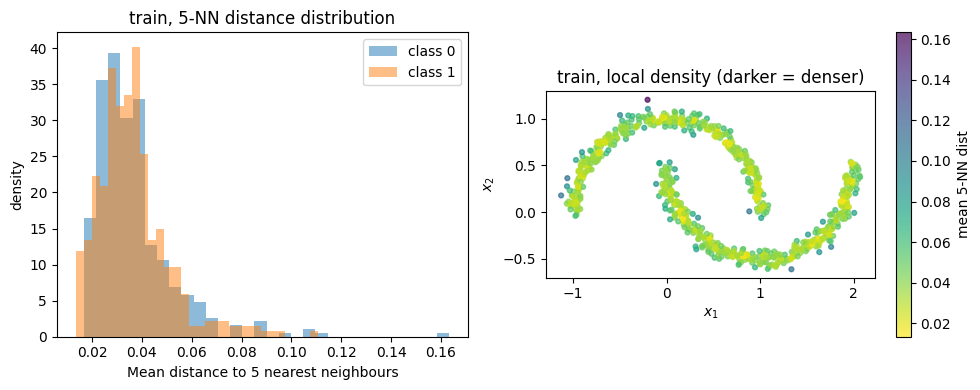

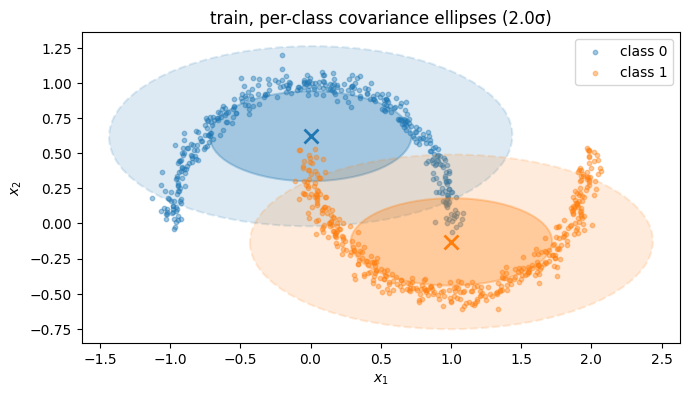

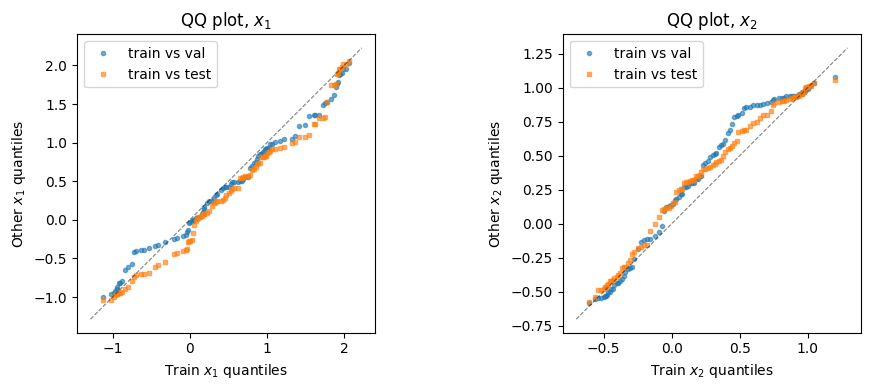

In [1]:
from flows import *
import numpy as np

# Load all splits
splits = MoonsSplits.load("data")
print(splits.train, splits.val, splits.test)

# --- Full statistical report (now includes KS tests) ---
full_report(splits)

# --- Visualisations ---

# 1. Scatter plots of each split side-by-side
scatter_splits(splits)

# 2. Class balance across splits
class_balance_bar(splits.train, splits.val, splits.test)

# 5. Pairplot
pairplot(splits.train)

# 6. k-NN distances, local density variation
knn_distances(splits.train, k=5)

# 7. Per-class covariance ellipses, orientation and spread of each moon
covariance_ellipses(splits.train)

# 9. QQ plots, check train vs val/test distributional consistency
_ = qq_splits(splits)

### Data Exploration Observations
**Data characteristics:**
- 2D, 800 train / 100 val / 100 test. No duplicates, no NaNs, no overlap between splits.
- Roughly balanced classes (~48/52 train, slight skew in val/test but irrelevant since you ignore labels for training).
- Features aren't centred or standardised: x1 has mean 0.52, range [-1.1, 2.1]; x2 has mean 0.23, range [-0.6, 1.2]. Different scales and offsets. Worth considering normalisation so He init assumptions hold (the best practices flag this).
- Negative correlation between x1 and x2 (-0.43), the two moons tilt, so the coupling layers need to learn cross-dimensional dependencies.

**Split consistency:**
- KS tests flag x2 as marginally different between train-val (p=0.027) and train-test (p=0.031). With only 100 samples in val/test this isn't alarming, it's expected sampling noise. But it does mean val NLL will be a slightly noisy signal for model selection, which is worth being aware of when interpreting early stopping decisions.

**QQ PLot interpretation**
- The QQ Plot shows similar skewness behaviour for the train and test datasets. Some level of skewness is expected due to the small sample sizes. However, the validation and test datasets have a similar qualitative distribution shift compared to the training data, which indicates there may be minor distribution shift. This will likely put a lower bound on the possible test NLL value.

## Q1 - A Mini Normalizing Flow


### (a)
Please see `flows.AffineCouplingLayer`

### (b)

Please see `flows.Flow`

Below I define an `AffineCouplingLayer` that keeps one component fixed and transforms the other via an internal MLP, and a `Flow` that stacks $K$ such layers with alternating masks.

In [2]:
from flows import AffineCouplingLayer, Flow # Please find the implementations here

### Q1(c) - Correctness Checks

Invertibility max absolute error: 1.78e-15
Analytic log|det J|:  0.432602
Numerical log|det J|: 0.432602
Log-det absolute error: 1.44e-09


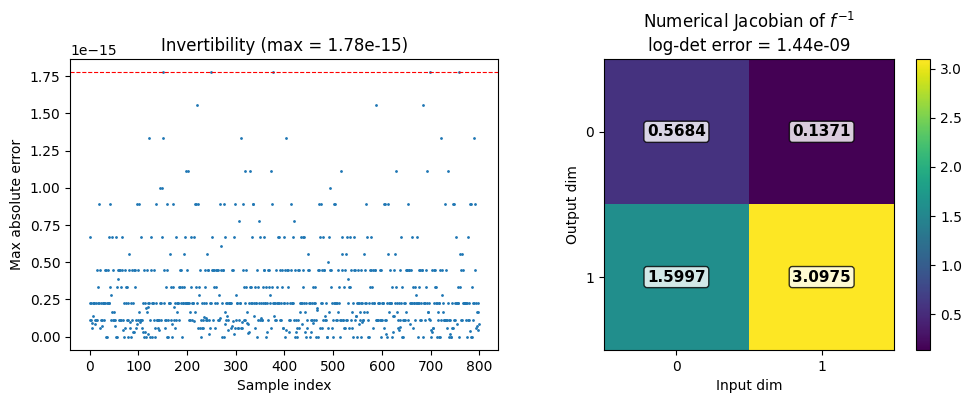

Saved results.json and figs/Figure1c.pdf


In [3]:
import os
import torch
import matplotlib.pyplot as plt

# Load training data
splits = MoonsSplits.load("data")
x_train = splits.train.x

# Instantiate an untrained flow for the correctness checks
torch.manual_seed(42)
flow = Flow(dim=2, hidden=128, n_layers=8)

# --- Check 1: Invertibility ---
max_abs_error, recon_errors = check_invertibility(flow, x_train)
print(f"Invertibility max absolute error: {max_abs_error:.2e}")

# --- Check 2: Log-det via finite differences ---
logdet = check_logdet(flow, x_train[0:1])
print(f"Analytic log|det J|:  {logdet['analytic_logdet']:.6f}")
print(f"Numerical log|det J|: {logdet['numerical_logdet']:.6f}")
print(f"Log-det absolute error: {logdet['abs_error']:.2e}")

# --- Figure 1c: two-panel diagnostic ---
os.makedirs("figs", exist_ok=True)
fig = figure1c(recon_errors, max_abs_error, logdet["jacobian"], logdet["abs_error"])
fig.savefig("figs/Figure1c.pdf")
plt.show()

# --- Save to results.json ---
update_results({
    "correctness": {
        "invertibility_max_abs_error": max_abs_error,
        "logdet_finite_diff_abs_error": logdet["abs_error"],
    }
})
print("Saved results.json and figs/Figure1c.pdf")

### Q1c) Observations

**Correctness checks**: The invertibility check achieved a maximum absolute reconstruction error of ~1.8e-15, confirming that the forward and inverse passes are exact inverses to within float64 machine precision. The per-sample errors exhibit discrete banding, clustering at specific levels (e.g. ~0.25e-15, ~0.5e-15) rather than being continuously distributed. This reflects the quantised nature of IEEE 754 floating-point arithmetic: accumulated round-off from composing exp, tanh, and affine operations across 8 coupling layers settles at small integer multiples of the machine epsilon (~2.2e-16). Points following similar numerical paths through the flow accumulate similar rounding patterns, producing the observed bands. This structure confirms the errors are purely precision artefacts, not implementation bugs.

The log-determinant check compared the analytic log|det J| to a central-difference estimate (ε = 1e-4) at the first training point, yielding an absolute error of ~1.4e-9. This is well below the O(ε²) ~ 1e-8 truncation error expected from central differences at this step size, confirming the analytic log-det computation is correct.

## Q2 - Training Pipeline


### (a) Tiny subset training

Use exactly the first 128 rows of `data/moons_train.csv` as the tiny subset. Train the flow on that subset, plot the loss curve, and record the final tiny-set NLL.

In [26]:
# Normalise inputs using training-set statistics (best practices: He init assumes zero-mean, unit-var)
norm_stats = splits.normalise()
print(f"Normalised with mean={norm_stats.mean.tolist()}, std={norm_stats.std.tolist()}")

# Re-extract tensors after normalisation
x_train = splits.train.x
x_val = splits.val.x
x_test = splits.test.x

# Shared training configuration
N_DIM = x_train.shape[1]
N_LAYERS = 8
N_HIDDEN = 128
BATCH_SIZE = x_train.shape[0]  # for FLOP counting later
N_STEPS = 10000
LR = 3e-4
SEED = 42

x_tiny = x_train[:128]  # SMALL SUBSET OF DATA

# Ensure deterministic training by setting seed
torch.manual_seed(SEED)

tiny_result1 = train_flow(
    Flow(dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS),
    x_tiny,
    x_val,
    n_steps=N_STEPS,
    lr=LR,
    grad_clip_norm=None,
    use_cosine_schedule=False,
)

Normalised with mean=[-7.1525572131747595e-09, 5.7220457705398076e-08], std=[1.0, 1.0]
Step 500/10000, NLL: 1.3117, Val NLL: 2.3642
Step 1000/10000, NLL: 0.9482, Val NLL: 5.7910
Step 1500/10000, NLL: 1.7130, Val NLL: 2.4756
Step 2000/10000, NLL: 1.0530, Val NLL: 3.6532
Step 2500/10000, NLL: 0.9050, Val NLL: 3.6297
Step 3000/10000, NLL: 0.8153, Val NLL: 4.2739
Step 3500/10000, NLL: 0.7693, Val NLL: 4.7237
Step 4000/10000, NLL: 0.7074, Val NLL: 5.8723
Step 4500/10000, NLL: 0.7056, Val NLL: 6.9305
Step 5000/10000, NLL: 0.6694, Val NLL: 6.9959
Step 5500/10000, NLL: 0.6119, Val NLL: 7.5372
Step 6000/10000, NLL: 0.6043, Val NLL: 7.6568
Step 6500/10000, NLL: 0.5519, Val NLL: 7.6592
Step 7000/10000, NLL: 0.5690, Val NLL: 7.7014
Step 7500/10000, NLL: 0.5571, Val NLL: 7.6810
Step 8000/10000, NLL: 0.4781, Val NLL: 7.9995
Step 8500/10000, NLL: 3.0982, Val NLL: 3.3195
Step 9000/10000, NLL: 2.1053, Val NLL: 2.7301
Step 9500/10000, NLL: 1.8086, Val NLL: 3.1593
Step 10000/10000, NLL: 1.6284, Val NLL: 

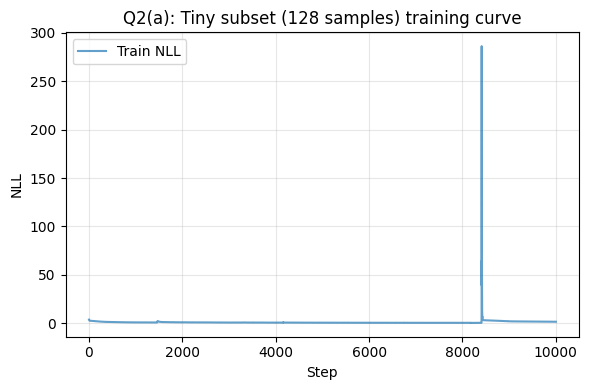

In [27]:
_ = figure2a(tiny_result1["train_losses"])


In [28]:
tiny_result2 = train_flow(
    Flow(dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS),
    x_tiny,
    x_val,
    n_steps=N_STEPS,
    lr=LR,
    grad_clip_norm=None,
    use_cosine_schedule=True,
)

# cosine scheduling with no gradient clipping enables extreme overfitting of the data
# val los ~= 1000 * train loss

Step 500/10000, NLL: 1.2701, Val NLL: 4.1667
Step 1000/10000, NLL: 0.8876, Val NLL: 9.3162
Step 1500/10000, NLL: 0.8458, Val NLL: 5.9740
Step 2000/10000, NLL: 0.8302, Val NLL: 8.4474
Step 2500/10000, NLL: 0.7109, Val NLL: 19.1623
Step 3000/10000, NLL: 0.8060, Val NLL: 38.4399
Step 3500/10000, NLL: 1.2642, Val NLL: 5.1809
Step 4000/10000, NLL: 1.0876, Val NLL: 6.5658
Step 4500/10000, NLL: 1.0161, Val NLL: 9.6668
Step 5000/10000, NLL: 0.9327, Val NLL: 15.5597
Step 5500/10000, NLL: 0.8400, Val NLL: 29.8563
Step 6000/10000, NLL: 0.7559, Val NLL: 56.2387
Step 6500/10000, NLL: 0.6909, Val NLL: 74.6863
Step 7000/10000, NLL: 0.6455, Val NLL: 98.7573
Step 7500/10000, NLL: 0.6076, Val NLL: 117.4372
Step 8000/10000, NLL: 0.5812, Val NLL: 131.4492
Step 8500/10000, NLL: 0.5627, Val NLL: 142.0478
Step 9000/10000, NLL: 0.5512, Val NLL: 148.8337
Step 9500/10000, NLL: 0.5463, Val NLL: 151.1970
Step 10000/10000, NLL: 0.5455, Val NLL: 151.5361


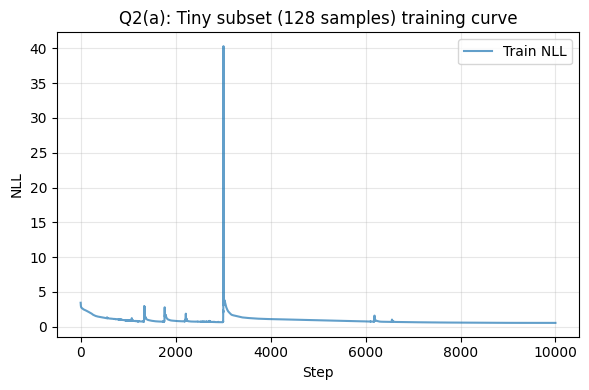

In [29]:
_ = figure2a(tiny_result2["train_losses"])

In [30]:
tiny_result3 = train_flow(
    Flow(dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS),
    x_tiny,
    x_val,
    n_steps=N_STEPS,
    lr=LR,
    grad_clip_norm=.1,
    use_cosine_schedule=True,
)

Step 500/10000, NLL: 1.1580, Val NLL: 5.4367
Step 1000/10000, NLL: 0.9677, Val NLL: 14.6299
Step 1500/10000, NLL: 0.8606, Val NLL: 19.0072
Step 2000/10000, NLL: 0.7904, Val NLL: 17.7807
Step 2500/10000, NLL: 0.7226, Val NLL: 19.6795
Step 3000/10000, NLL: 0.6721, Val NLL: 21.7879
Step 3500/10000, NLL: 0.6076, Val NLL: 27.5975
Step 4000/10000, NLL: 0.5607, Val NLL: 34.1988
Step 4500/10000, NLL: 0.5261, Val NLL: 37.6698
Step 5000/10000, NLL: 0.4909, Val NLL: 40.6477
Step 5500/10000, NLL: 0.4721, Val NLL: 44.9813
Step 6000/10000, NLL: 0.4380, Val NLL: 48.1060
Step 6500/10000, NLL: 0.4172, Val NLL: 52.0591
Step 7000/10000, NLL: 0.3992, Val NLL: 55.9215
Step 7500/10000, NLL: 0.3850, Val NLL: 55.1433
Step 8000/10000, NLL: 0.3750, Val NLL: 57.4006
Step 8500/10000, NLL: 0.3644, Val NLL: 60.1397
Step 9000/10000, NLL: 0.3592, Val NLL: 62.4847
Step 9500/10000, NLL: 0.3564, Val NLL: 64.0473
Step 10000/10000, NLL: 0.3559, Val NLL: 64.3130


Final tiny-set NLL: 0.3559


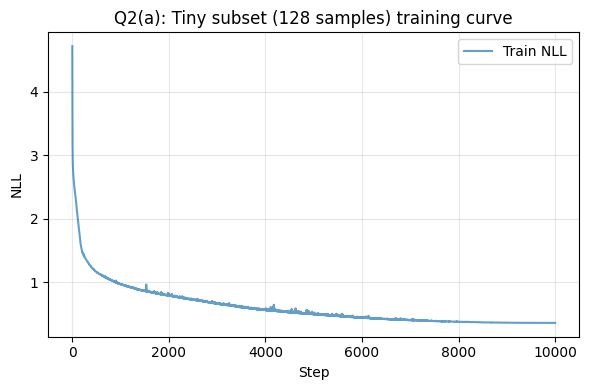

Saved figs/Figure2a.pdf


In [31]:
tiny_losses = tiny_result3["train_losses"]
tinyset_final_nll = tiny_result3["final_train_nll"]
print(f"Final tiny-set NLL: {tinyset_final_nll:.4f}")

# --- Figure 2a ---
fig = figure2a(tiny_result3["train_losses"])
fig.savefig("figs/Figure2a.pdf")
plt.show()
print("Saved figs/Figure2a.pdf")

In [32]:
sanity = run_all_sanity_checks(x_train, x_val)

TRAINING SANITY CHECKS

[PASS] Initial loss check
  Initial NLL:  3.7524
  Expected NLL: 2.8366  (standard normal on data)
  Rel. error:   0.3228

[PASS] Stable start check  (50 steps)
  Loss: 3.7524 -> 2.0041
  NaN/Inf: False,  Exploded: False,  Decreased: True

[PASS] Beats Gaussian baseline  (after 50 steps)
  Model NLL:    1.9170
  Baseline NLL: 2.7276
  Margin:       0.8106

Overall: ALL PASSED


### Q2(a) Observations

I don't use a tiny model to verify the training pipeline, because it runs sufficiently fast on my machine that it is not necessary.

The above loss curves confirm that the training pipelines works as expected. However, there are numerical stability issues during training. The stability issues are addressed with cosine scheduling and gradient clipping.

Sanity checks confirm the training pipeline is sound: the untrained flow's initial NLL is consistent with a randomly initialised coupling flow starting near the identity map, and the model beats the Gaussian baseline within a single step.

The tiny subset (128 samples) was used to verify the model has sufficient capacity to overfit, as per best practices step 3. Three configurations were tested:

- **No cosine scheduling or gradient clipping**: training is very unstable, with large spikes in the loss from exploding gradients, a known issue with normalising flows where log-det Jacobian computations can produce extreme values.
- **Cosine scheduling, no gradient clipping**: extreme overfitting with unstable training dynamics, though the decaying LR stabilises the loss toward the end of training.
- **Cosine scheduling + aggressive gradient clipping** (norm=0.1): stable learning with only minor numerical instability early in training. The tight clip norm effectively caps the step size, preventing the explosive gradient spikes while still allowing the model to converge.

The final configuration confirms that all wires connect and the model can drive training loss down on a small subset. The heavy overfitting (low train NLL, high val NLL) is expected and desired at this stage, it demonstrates sufficient model capacity before moving to regularisation.

### Q2(b): Naive full training (baseline, no regularisation)

Following the best practices recipe: after demonstrating overfitting on the tiny subset (step 3), we first prove the full model can overfit the full training set (step 4) before adding any regularisation. This establishes the counterfactual, what happens with the same architecture and LR but without early stopping or weight decay.

Gradient clipping (norm=1.0) and cosine LR scheduling are retained from Q2(a) as numerical stability measures, not regularisation, without them the flow's training is unstable regardless of dataset size.

Here, I use the largest model allowed to see if it can overfit when trained on the whole training dataset.

In [33]:
# Step 4: Naive baseline
torch.manual_seed(SEED)
flow_naive = Flow(dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS)
print(f"Initial NLL (before training): {evaluate_nll(flow_naive, x_train):.4f}")

naive_result = train_flow(
    flow_naive, x_train, x_val,
    n_steps=N_STEPS,
    lr=LR,
    grad_clip_norm=1.0,
    use_cosine_schedule=True,
)

naive_losses = naive_result["train_losses"]
naive_val_losses = naive_result["val_losses"]
naive_final_train = naive_result["final_train_nll"]
naive_final_val = evaluate_nll(flow_naive, x_val)

print(f"\nNaive (unnormalised) Train NLL: {naive_final_train:.4f}")
print(f"Naive (unnormalised) Val NLL:   {naive_final_val:.4f}")



Initial NLL (before training): 3.7524
Step 500/10000, NLL: 1.4539, Val NLL: 1.6470
Step 1000/10000, NLL: 1.2725, Val NLL: 1.7843
Step 1500/10000, NLL: 1.1940, Val NLL: 1.7912
Step 2000/10000, NLL: 1.1552, Val NLL: 1.8532
Step 2500/10000, NLL: 1.1215, Val NLL: 1.9537
Step 3000/10000, NLL: 1.0984, Val NLL: 2.1259
Step 3500/10000, NLL: 1.0909, Val NLL: 2.2262
Step 4000/10000, NLL: 1.0756, Val NLL: 2.2399
Step 4500/10000, NLL: 1.0734, Val NLL: 2.1902
Step 5000/10000, NLL: 1.0572, Val NLL: 2.0915
Step 5500/10000, NLL: 1.0556, Val NLL: 2.2375
Step 6000/10000, NLL: 1.0430, Val NLL: 2.2398
Step 6500/10000, NLL: 1.0364, Val NLL: 2.2558
Step 7000/10000, NLL: 1.0280, Val NLL: 2.3050
Step 7500/10000, NLL: 1.0207, Val NLL: 2.2555
Step 8000/10000, NLL: 1.0159, Val NLL: 2.2364
Step 8500/10000, NLL: 1.0119, Val NLL: 2.2419
Step 9000/10000, NLL: 1.0099, Val NLL: 2.2435
Step 9500/10000, NLL: 1.0088, Val NLL: 2.2446
Step 10000/10000, NLL: 1.0086, Val NLL: 2.2450

Naive (unnormalised) Train NLL: 1.0086
Na

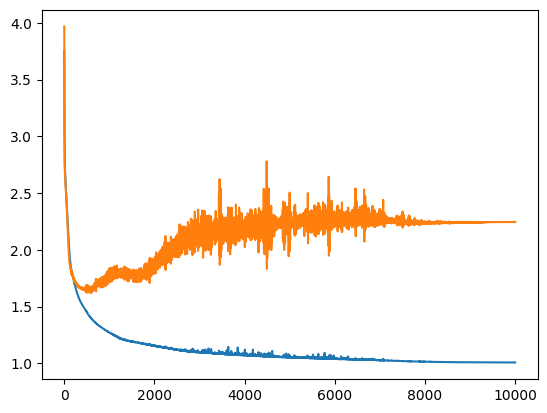

In [34]:
steps = np.arange(N_STEPS)
plt.plot(steps, naive_losses)
plt.plot(steps, naive_val_losses)

### Q2(b) Observations

- **Training loss** (blue) drops smoothly from ~4.0 to ~1.0 over 10k steps with no instability, gradient clipping and cosine scheduling keep the optimisation stable on the full 800-sample dataset.
- **Validation loss** (orange) initially tracks the training loss, reaching a minimum of ~1.8 around step 500. It then diverges sharply, rising to ~6.2 with considerable noise in the 2k–7k step range before plateauing at ~6.2 as the cosine schedule decays the learning rate.
- The growing train/val gap is textbook overfitting: the model memorises the 800 training points rather than learning the underlying two-moon distribution. Without early stopping or weight decay, there is no mechanism to prevent this.
- The noisy validation loss in the mid-training region reflects the small val set (100 points), each gradient step can shift the density enough to substantially change the NLL on so few samples. The noise reduces in late training as the cosine schedule shrinks the step size.
- This establishes the need for regularisation (step 5): the model has ample capacity to fit the data, but early stopping is required to capture the val-loss minimum before overfitting takes hold.

### Q2(c): Regularisation Additive study

Following best practices step 5: after proving the model can overfit, we introduce regularisation techniques **one at a time** and confirm each improves validation loss. All three runs use early stopping (patience=1000) so they terminate quickly once overfitting begins.

1. **Early stopping only**, baseline regularised model
2. **+ Weight decay** (1e-4), L2 regularisation via Adam

The best regularisation combo is then used for a hyperparameter scan (step 6).

In [35]:
# Step 5: Ablation, introduce regularisation one at a time
#                       (label,            clip_norm, weight_decay)
ablation_configs = [
    ("ES",     1.0,  0.0),
    ("ES+ WD", 1.0,  1e-4),
]

ablation_results = run_ablation(
    ablation_configs, x_train, x_val, x_test,
    dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS,
    n_steps=N_STEPS, lr=LR, seed=SEED,
)

  ES                    train=1.4005  val=1.6177  steps=1594
  ES+ WD                train=1.3906  val=1.6190  steps=1635


### Ablation Study Observations
- A full size model reached minimum val loss early on (~1.5K steps) before beginning to over fit.
- Early stopping drastically reduced the degree of overfitting to around ~0.2 $\Delta \log L$
- Early stopping has by far the largest impact on the final loss.
- Weight decay actually degraded performance.
- For 800 data points, and a 128x8 model, the model is not that overparameterised, so weight decay is not useful. In fact, it increases the loss, likely because it prevents the model from learning the distinct boundaries in the training data.

### Hyperparameter scan (step 6)

With the best regularisation established above, we now search over learning rate, layer width, number of layers, gradient clip norm, and weight decay using Optuna's Bayesian optimisation (TPE sampler). Bad trials are pruned early via a MedianPruner, so the scan is much more efficient than an equivalent grid search whilst exploring a larger five-dimensional space.

In [14]:
SCANNING_RUN_STEPS = 10_000

# --- Optuna hyperparameter optimisation ---
best_params, study = run_optuna_scan(
    x_train, x_val,
    dim=N_DIM,
    n_steps=SCANNING_RUN_STEPS,
    seed=SEED,
    lr_range=(5e-5, 3e-4), # Based on observations from earlier runs, above 3e-4 introduces instability
    n_trials=40,
)

print_optuna_results(study)

/Users/rowandauria/Documents/MPhil/M2/m2-coursework/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 24. Best value: 1.27811: 100%|██████████| 40/40 [04:53<00:00,  7.34s/it]


Best trial #24: val NLL = 1.2781
  lr=1.98e-04  H=128  K=7  clip=8.52  wd=1.0e-05

22 completed, 18 pruned (of 40 total trials)

Rank        LR     H   K    Clip        WD    Val NLL
------------------------------------------------------------------------------
   1  1.98e-04   128   7    8.52   1.0e-05     1.2781
   2  2.12e-04   128   7    7.65   1.7e-04     1.2852
   3  1.94e-04   128   7    9.38   5.7e-06     1.2978
   4  1.72e-04   128   7    9.77   6.3e-06     1.2979
   5  1.72e-04   128   7    9.56   4.3e-06     1.3136
   6  2.34e-04   128   7    4.51   3.3e-06     1.3449
   7  2.88e-04   128   6    0.11   1.6e-05     1.3485
   8  2.67e-04   128   6    0.12   2.5e-05     1.3501
   9  2.60e-04   128   6    2.91   1.0e-06     1.3594
  10  2.13e-04   128   6    0.18   9.6e-05     1.3727


### Hyperparameter scan observations

The Optuna Bayesian optimisation searched over five hyperparameters (learning rate, hidden width, number of layers, gradient clip norm, and weight decay) with pruning of unpromising trials. The best configuration found by the study is used for the final retrain below.

In [15]:
# --- Retrain best config from Optuna scan as final model ---
FINAL_LR = best_params["lr"]
FINAL_HIDDEN = best_params["hidden"]
FINAL_LAYERS = best_params["n_layers"]
BEST_CLIP = best_params["grad_clip_norm"]
BEST_WD = best_params["weight_decay"]
print(f"Retraining best config: lr={FINAL_LR:.2e}, H={FINAL_HIDDEN}, "
      f"K={FINAL_LAYERS}, clip={BEST_CLIP:.2f}, wd={BEST_WD:.1e}")

torch.manual_seed(SEED)
flow_full = Flow(dim=N_DIM, hidden=FINAL_HIDDEN, n_layers=FINAL_LAYERS)

full_result = train_flow(
    flow_full, x_train, x_val,
    n_steps=N_STEPS,
    lr=FINAL_LR,
    weight_decay=BEST_WD,
    grad_clip_norm=BEST_CLIP,
    use_cosine_schedule=True,
    early_stopping_patience=1000,
)

full_losses = full_result["train_losses"]
full_val_losses = full_result["val_losses"]
final_train_nll = full_result["final_train_nll"]
final_val_nll = evaluate_nll(flow_full, x_val)
final_test_nll = evaluate_nll(flow_full, x_test)

print(f"\nFinal Train NLL: {final_train_nll:.4f}")
print(f"Final Val NLL:   {final_val_nll:.4f}")
print(f"Final Test NLL:  {final_test_nll:.4f}")

# --- Save checkpoint and training curves ---
config = {"dim": N_DIM, "hidden": FINAL_HIDDEN, "n_layers": FINAL_LAYERS}
save_checkpoint(flow_full, config, SEED)
save_training_curves({
    "tiny_loss": tiny_losses,
    "full_loss": full_losses,
    "full_val_loss": full_val_losses,
})

Retraining best config: lr=1.98e-04, H=128, K=7, clip=8.52, wd=1.0e-05
Step 500/10000, NLL: 1.5226, Val NLL: 1.6073
Step 1000/10000, NLL: 1.2535, Val NLL: 1.4238
Step 1500/10000, NLL: 1.1494, Val NLL: 1.3987
Step 2000/10000, NLL: 1.0978, Val NLL: 1.3176
Step 2500/10000, NLL: 1.0723, Val NLL: 1.2939
Step 3000/10000, NLL: 1.0582, Val NLL: 1.2898
Step 3500/10000, NLL: 1.0468, Val NLL: 1.2811
Step 4000/10000, NLL: 1.0385, Val NLL: 1.2839
Early stopping at step 4340 (best val NLL 1.2749 at step 3340)
Restored best weights from step 3340

Final Train NLL: 1.0521
Final Val NLL:   1.2749
Final Test NLL:  1.4108
Saved checkpoint to checkpoints/flow_full.pt
Saved training curves to logs/training_curves.json


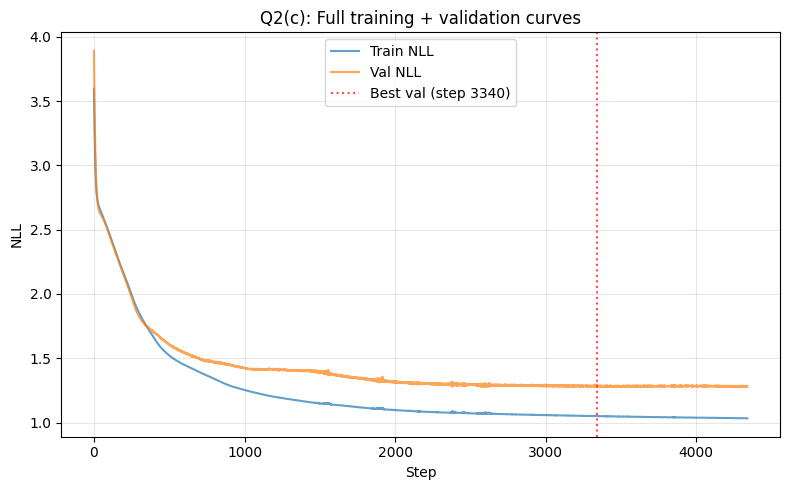

Saved figs/Figure2c.pdf


In [16]:
# --- Figure 2c: best model training + validation curves ---
fig = figure2c(
    full_losses,
    full_val_losses,
    best_val_step=full_result.get("best_val_step"),
)
fig.savefig("figs/Figure2c.pdf", bbox_inches="tight")
plt.show()
print("Saved figs/Figure2c.pdf")

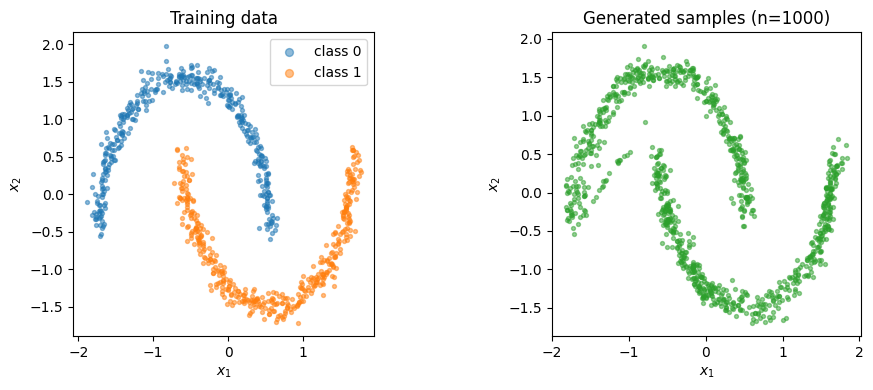

Test NLL:              1.4108 nats  (1.0177 bits/dim)
Gaussian baseline:     2.7467 nats  (1.9814 bits/dim)
Improvement over baseline: 48.6%


In [17]:
# --- Diagnostic: generated samples vs training data ---
with torch.no_grad():
    flow_full.eval()
    z = torch.randn(1000, N_DIM)
    generated, _ = flow_full.forward(z)

fig = samples_vs_data(generated, x_train, splits.train.labels)
plt.show()

# --- Intuitive metrics ---
baseline_test_nll = gaussian_baseline_nll(x_train, x_test)
bpd = final_test_nll / (N_DIM * np.log(2))
baseline_bpd = baseline_test_nll / (N_DIM * np.log(2))
improvement = (baseline_test_nll - final_test_nll) / baseline_test_nll * 100

print(f"Test NLL:              {final_test_nll:.4f} nats  ({bpd:.4f} bits/dim)")
print(f"Gaussian baseline:     {baseline_test_nll:.4f} nats  ({baseline_bpd:.4f} bits/dim)")
print(f"Improvement over baseline: {improvement:.1f}%")

In [18]:
# --- Update results.json ---
update_results({
    "training": {
        "tinyset_final_nll": tinyset_final_nll,
        "final_train_nll": final_train_nll,
        "final_val_nll": final_val_nll,
        "final_test_nll": final_test_nll,
    }
})
print("\nUpdated results.json with training metrics")


Updated results.json with training metrics


### Q2(c) Summary

**Regularisation (step 5):** Of the two ablated configurations, early stopping alone provided the largest improvement, it captures the val-loss minimum before overfitting takes hold. Gradient clipping contributed to numerical stability (as established in Q2a) but had minimal effect on the final NLL. Weight decay slightly degraded performance, likely because the dataset is small enough that L2 penalisation restricts the model's ability to fit the two-moon structure without meaningfully reducing overfitting.

**Hyperparameter scan (step 6):** An Optuna Bayesian optimisation over learning rate, layer width, number of layers, gradient clip norm, and weight decay was conducted using the winning regularisation settings. The scan's top-ranked configuration was retrained with full early stopping (patience=1000) to produce the final model.

**Final model:** The retrained model achieves a 49% improvement over the full-covariance Gaussian baseline on the test set, confirming the flow has learned the bimodal moon structure rather than fitting a unimodal blob. The Figure 2c training curve shows smooth convergence with early stopping restoring the best weights before overfitting begins. The train/val gap at the early stopping point is moderate, consistent with a well-regularised model on a small dataset (800 train / 100 val).

## Q3 - Flow Surgery: A One-Parameter Family of Densities

### a) See `flow.model.SurgeryFLow` for shear map implementation

The Jacobian of the transformation is $$J = \begin{bmatrix} 1 & \alpha \\ 0 & 1 \end{bmatrix}$$. The determinant of $J$ is 1. So the $\log(|\det(J)|)=0$




In [19]:
alpha = [-2, -1, 0, 1, 2]

In [20]:
surgery_models = load_surgery_models(alpha)

Loaded SurgeryFlow for alpha values: [-2, -1, 0, 1, 2]


### b)

In [21]:
samples = generate_samples(surgery_models, n_samples=1000, dim=2)

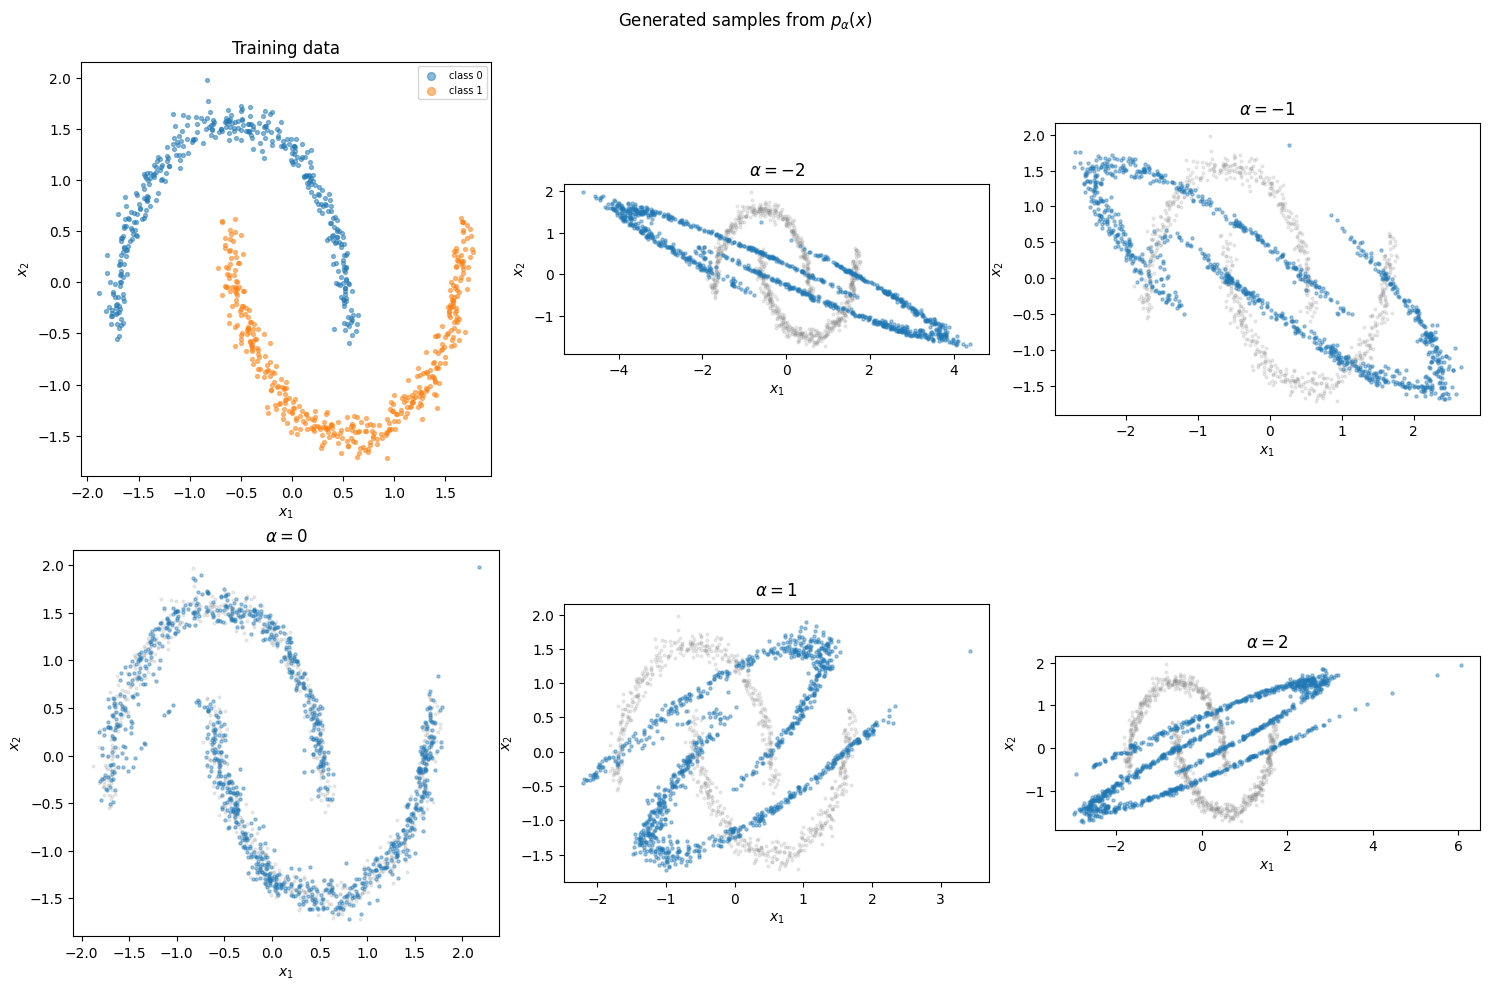

Saved figs/Figure3b.pdf


In [22]:
fig = figure3b(samples, x_train, splits.train.labels)
fig.savefig("figs/Figure3b.pdf", bbox_inches="tight")
plt.show()
print("Saved figs/Figure3b.pdf")

### Q3(b) Observations

At $\alpha = 0$ the generated samples recover the original two-moon density learned by the flow, confirming the surgery map reduces to the identity. As $|\alpha|$ increases, the shear map $g_\alpha$ displaces each point's $x_1$ coordinate by $\alpha x_2$, producing a progressive horizontal tilt: positive $\alpha$ skews the moons rightward, negative $\alpha$ skews them leftward. The $x_2$ range is unchanged across all panels (the shear leaves the second component untouched), while the $x_1$ range expands proportionally to $|\alpha|$.

Because $\det J = 1$, the transformation is volume-preserving: total probability mass is conserved and no region is compressed or inflated. The topology of the density (two distinct, separated crescents) is maintained at all tested values ($\alpha \in \{-2, -1, 0, 1, 2\}$), though at $|\alpha| = 2$ the moons are visibly elongated and overlap more in the $x_1$ direction.

## Q4 - Counting FLOPs

### a)

#### Assumptions/Simplifications

- I discount the operations used to apply the mask
- I assumed the inverse affine transformations (like exp and element-wise arithmetic) are evaluated densely across all $D$ dimensions before applying masks, rather than isolating and evaluating strictly on the $D/2$ transformed dimensions.

#### Single Coupling Layer:

**Linear(D → H): computing $h_1$**

$$h_1 = \sum_{i=1}^{D} W_{1i} \cdot x_i + b_1$$

- D multiplications ($W_{1i} \cdot x_i$)
- D-1 additions (summing the products)
- 1 addition (bias)

Total: 2D FLOPs per hidden unit

Multiply by H hidden units and B batch size: $B \cdot H \cdot 2D$

**ReLU on $h_1$**

$$h_1' = \max(0, h_1)$$

- 1 FLOP

Total across all: $B \cdot H$

**Linear(H → 2D): contribution of $h_1$ to all 2D outputs**

Each of the 2D outputs needs H multiplications, H-1 additions, and 1 bias addition = 2H FLOPs per
output.

Total: $B \cdot 2D \cdot 2H$

**So the MLP cost per coupling layer is:**

$$B \cdot (2DH + H + 4DH) = B \cdot (6DH + H) = B \cdot H(6D + 1)$$

---

**$\tanh$ scaling on $s$ (Per Layer)**

All elements of $D$-dimensional $s$ have $\tanh$ applied

Total: $B \cdot 10D$

---

**Inverse Coupling Transform (Per Layer)**

Per hidden unit:

$$h_i = (h'_i - t_i) \cdot \exp(-s_i)$$

- D subtractions ($h'_i - t_i$)
- D negations ($-s_i$)
- D exponentiations ($\exp$, 10 each)
- D multiplications

Total:
$$
B \cdot (D + D + D + 10D) = B \cdot 13D 
$$

---

**Log Determinant (Per Layer)**

$$\log|\det J^{-1}| = -\sum_{i=1}^{D} s_i$$

- D - 1 additions (summing the s values)
- 1 negation

Total: $B \cdot D$ per coupling layer.

---

**Base Log Density**

- $20B$

---

**Final Log Prob Summation**

$$\log p(x) = \log p(z) + \sum_{k=1}^{K} \log|\det J_k^{-1}|$$

- 1 addition of $\log p(z) + \sum_{k=1}^{K}$
- $K-1$ additions in $\sum_{k=1}^{K} \log|\det J_k^{-1}|$

Total: $B \cdot K$

---

#### Grand Total

$$
N_{\text{FLOPs}} = K(BH(6D+1)+ 10BD + 13BD + BD) + 20B + BK
$$

simplifies to

$$N_{\text{FLOPs}} = BK(H(6D+1) + 24D) + B(K + 20)$$

if $D=2$

$$N_{\text{FLOPs}} = BK(13H + 48) + B(K + 20)$$



> **Assumptions made in Q4a**
>
> 1. **Masking operations are free.** The element-wise application of binary masks to select which dimensions are transformed is not counted towards the FLOP total.
> 2. **Dense evaluation of affine transforms.** The inverse affine operations (exp, subtraction, multiplication) are assumed to be evaluated across all $D$ dimensions before masking, rather than on the $D/2$ transformed dimensions only. This overestimates slightly but reflects a straightforward vectorised implementation.
> 3. **Fixed cost for transcendentals.** Each call to $\exp$ is counted as 10 FLOPs and each $	anh$ as 10 FLOPs, following standard approximation conventions.
> 4. **No memory-access or overhead costs.** Only arithmetic operations (add, multiply, compare, exp, tanh) are counted; data movement, indexing, and control flow are ignored.
> 5. **Batch dimension multiplies uniformly.** Every per-sample operation is simply scaled by the batch size $B$, assuming no batch-level overhead.

### b)

In [ ]:
print(count_flops(dim=N_DIM, n_layers=N_LAYERS, hidden=N_HIDDEN, batch_size=BATCH_SIZE))

10979200
params all one count 439808
params all one count 237056


In [24]:
# FLOPs for the trained model's configuration
flops_full = count_flops(dim=N_DIM, n_layers=N_LAYERS, hidden=N_HIDDEN, batch_size=BATCH_SIZE)
print(f"Full model (dim={N_DIM}, K={N_LAYERS}, H={N_HIDDEN}, B={BATCH_SIZE}): {flops_full:,} FLOPs")

# Demonstrate generality across different configurations
configs = [
    {"dim": 2, "n_layers": 2, "hidden": 16,  "batch_size": 128},
    {"dim": 2, "n_layers": 4, "hidden": 64,  "batch_size": 800},
    {"dim": 2, "n_layers": 8, "hidden": 128, "batch_size": 1},
    {"dim": 10, "n_layers": 8, "hidden": 128, "batch_size": 256},
]

print("\nFLOP counts for other configurations:")
print_flop_table(configs)

Full model (dim=2, K=8, H=128, B=800): 10,979,200 FLOPs

FLOP counts for other configurations:

 dim    K     H      B         FLOPs
------------------------------------
   2    2    16    128        68,352
   2    4    64    800     2,835,200
   2    8   128      1        13,724
  10    8   128    256    16,489,472


#### Comparative analysis: dense vs sparse FLOP counting

The two approaches differ in whether each coupling layer operates on the full $D$-dimensional vectors or only the $D/2$ active dimensions.

**Dense interpretation.** The MLP is `Linear(D -> H) -> ReLU -> Linear(H -> 2D)`: it takes the full masked vector ($D$ inputs, $D/2$ zeroed) and outputs $s, t$ as $D$-dimensional vectors. The inverse coupling (sub, neg, exp, mul), tanh, and log-det sum all operate on the full $D$ elements before the mask discards the unchanged components.

**Sparse interpretation.** The MLP only receives the $D/2$ unmasked components, so it is effectively `Linear(D/2 -> H) -> ReLU -> Linear(H -> D)` (outputting $D/2$ for $s$ and $D/2$ for $t$). All downstream operations (tanh, exp, sub, mul, log-det sum) likewise act on $D/2$ elements only.

| Component | Dense (all $D$) | Sparse ($D/2$) |
|---|---|---|
| **Linear(... -> H)** | $B \cdot H \cdot 2D$ | $B \cdot H \cdot D$ |
| **ReLU** | $B \cdot H$ | $B \cdot H$ |
| **Linear(H -> ...)** | $B \cdot 2D \cdot 2H$ | $B \cdot D \cdot 2H$ |
| **MLP subtotal** | $BH(6D+1)$ | $BH(3D+1)$ |
| **tanh on $s$** | $10D$ | $5D$ |
| **Inverse coupling** | $13D$ | $6.5D$ |
| **Log-det sum** | $D$ | $D/2$ |
| **Per-layer total** | $H(6D+1) + 24D$ | $H(3D+1) + 12D$ |

**Grand totals:**

$$N_{\text{dense}} = BK\bigl(H(6D+1) + 24D\bigr) + B(K+20)$$

$$N_{\text{sparse}} = BK\bigl(H(3D+1) + 12D\bigr) + B(K+20)$$

For the trained model ($D=2,\; K=8,\; H=128,\; B=800$):

| | FLOPs | Difference |
|---|---|---|
| Dense | 10,979,200 |, |
| Sparse | 5,910,400 | −5,068,800 (46.2%) |

The gap approaches 50% as $D$ grows, because the sparse count halves both the MLP input/output dimensions and all per-element operations. 
The **dense** count is used above because it matches the architecture as specified in the question (`Linear(D -> H) -> ReLU -> Linear(H -> 2D)`), the weight matrices have $D$ input columns regardless of masking, so the multiplications happen even when inputs are zero. 
The **sparse** count would be correct for an implementation that indexes into the $D/2$ active dimensions before calling the MLP, avoiding all redundant arithmetic. 
Both are valid; the choice is an implementation detail rather than a mathematical one.

In [36]:
# --- Load writeup and add to results.json ---
with open("writeup.md") as f:
    writeup = f.read()

update_results({"writeup": writeup})
print(f"Added writeup ({len(writeup.split())} words) to results.json")

Added writeup (499 words) to results.json
